In [1]:
import sys
import os
import matplotlib.pyplot as plt
import cv2

import numpy as np

# Add the src directory to the path. TEMPORARY FIX
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from src.data_processing.dataset_loader import CoastData
from src.data_processing.dataset_preprocessor_bilstm import DatasetPreprocessorBiLSTM

In [2]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_oblique_v1.0.0/"))

# Load the data, all the different stations
data = CoastData(data_path, name="global")

filtered_data = data.get_images() 

print(filtered_data)

# filtered_data = data.split_data()

# Get the first image and mask
index = 1
image_path = filtered_data[index]['image']
mask_path = filtered_data[index]['mask']

print("Image:", image_path)
print("Mask:", mask_path)

CoastData: global - 1717 images
[{'image': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\SCLabels_oblique_v1.0.0\\images\\1548260289.Wed.Jan.23_17_18_09.CET.2019.agrelo.image.jpg', 'mask': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\SCLabels_oblique_v1.0.0\\masks\\1548260289.Wed.Jan.23_17_18_09.CET.2019.agrelo.mask.png'}, {'image': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\SCLabels_oblique_v1.0.0\\images\\1548430860.Fri.Jan.25_16_41_00.CET.2019.agrelo.image.jpg', 'mask': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\SCLabels_oblique_v1.0.0\\masks\\1548430860.Fri.Jan.25_16_41_00.CET.2019.agrelo.mask.png'}, {'image': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\SCLabels_oblique_v1.0.0\\images\\1548520320.Sat.Jan.26_17_32_00.CET.2019.agrelo.image.jpg', 'mask': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\SCLabels_oblique_v1.0.0\\masks\\1548520320.Sat.Jan.26_17_32_00.CE

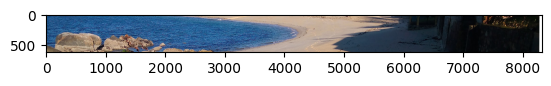

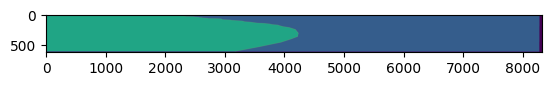

In [3]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(mask)

Image shape: (623, 8320, 3)
Mask shape: (623, 8320)


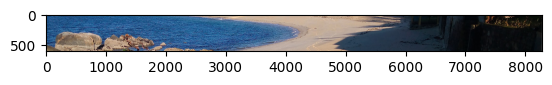

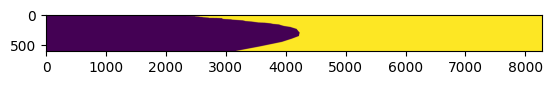

In [4]:
dataset_preprocessor_bilstm = DatasetPreprocessorBiLSTM()

image = dataset_preprocessor_bilstm.load_image(image_path)
mask = dataset_preprocessor_bilstm.load_mask(mask_path)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

mapping = {
    0: 2,    # Background → Class 2 (after the mapping, we will transform it to binary)
    25: 2,   # Not classified → Class 2 (after the mapping, we will transform it to binary)
    75: 1,   # Land → Class 2
    150: 0,  # Sea → Class 3
    255: 1   # Shoreline → Class 4
}

new_image, new_mask = dataset_preprocessor_bilstm.process_image(image, mask, mask_mapping=mapping)
new_image = cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)

plt.imshow(new_image)
plt.show()  

plt.imshow(new_mask)
plt.show()

In [5]:
new_data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/processed_oblique_bilstm_global/"))
dataset_preprocessor_bilstm.preprocess_from_metadata(metadata=data.metadata, dataset_path=filtered_data, dataset_output_path=new_data_path, mask_mapping=mapping)

In [13]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/processed_oblique_bilstm_global/"))

# Load the data, all the different stations
data = CoastData(data_path, name="cadiz")

filtered_data = data.get_images() 

print(filtered_data)

# filtered_data = data.split_data()

# Get the first image and mask
index = 25
image_path = filtered_data[index]['image']
mask_path = filtered_data[index]['mask']

print("Image:", image_path)
print("Mask:", mask_path)

CoastData: cadiz - 946 images
[{'image': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\processed_oblique_bilstm_global\\images\\1602845999.Fri.Oct.16_11_59_59.CET.2020.cadiz.image.jpg', 'mask': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\processed_oblique_bilstm_global\\masks\\1602845999.Fri.Oct.16_11_59_59.CET.2020.cadiz.mask.png'}, {'image': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\processed_oblique_bilstm_global\\images\\1602847056.Fri.Oct.16_12_17_36.CET.2020.cadiz.image.jpg', 'mask': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\processed_oblique_bilstm_global\\masks\\1602847056.Fri.Oct.16_12_17_36.CET.2020.cadiz.mask.png'}, {'image': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\processed_oblique_bilstm_global\\images\\1602847144.Fri.Oct.16_12_19_04.CET.2020.cadiz.image.jpg', 'mask': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\processed_oblique_bilstm_global\

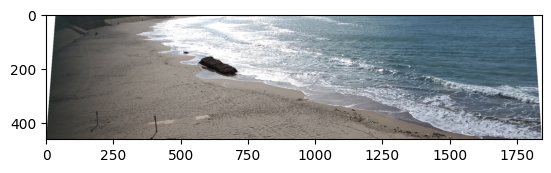

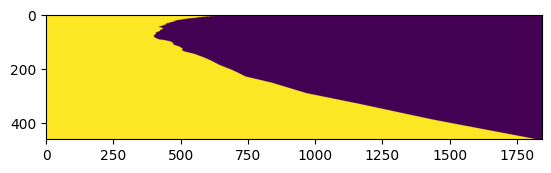

In [15]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(mask)